In [ ]:
import numpy as np
from scipy.integrate import solve_ivp
import scipy.sparse as sp
import matplotlib.pyplot as plt

# Exercise 17

a)

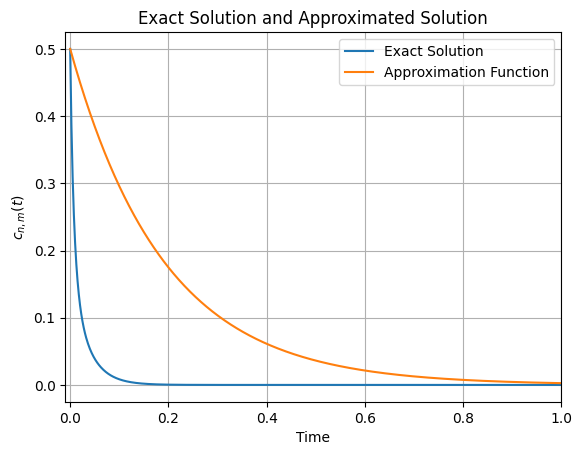

In [83]:
# System parameters
omega=1
d=5
gamma=0.5
N=5
Gamma=gamma*(2*N*2+1)

# Annihilation and creation operators
vec=np.sqrt(np.arange(1, d))
A=np.diag(vec, 1)  # annihilation operator
Adag=A.T           # creation operator

# Identity
id=np.identity(d)

# Hamiltonian
H=omega*(Adag@A+0.5*np.eye(d))

# Liouville operator
LH=-1j*(sp.kron(H,id)-sp.kron(id,H.T))
L1=Gamma/2*(N+1)*(2*sp.kron(A,Adag.T)-sp.kron(Adag@A,id)-sp.kron(id,(Adag@A).T))
L2=Gamma/2*N*(2*sp.kron(Adag,A.T)-sp.kron(A@Adag,id)-sp.kron(id,(A@Adag).T))
L =LH+L1+L2

# Initial state (superposition of |0> and |1>)
n=np.array([1,0,0,0,0])
m=np.array([0,1,0,0,0])
psi0=1/np.sqrt(2)*(n+m)
rho0=np.outer(psi0,psi0.conj())
rho_ini=rho0.flatten()

# Time evolution
t_steps=800
t_final=1
t_span=np.linspace(0,t_final,t_steps)

def rhodot(t,rho,L):
    return L.dot(rho)

sol=solve_ivp(rhodot,(t_span[0],t_span[-1]),rho_ini,t_eval=t_span,args=[L])
rho_t=sol.y
n_index=0  # example: ground state |0⟩
m_index=1  # example: first excited state |1⟩

cnm_t=[]

def f(t):
    l=1/2*np.exp(-Gamma*t/2)
    return l

for i in range(t_steps):
    rho_matrix=rho_t[:, i].reshape((d, d))
    cnm_t.append(rho_matrix[n_index, m_index])

cnm_t = np.array(cnm_t)
plt.plot(t_span, np.real(cnm_t), label='Exact Solution')
plt.plot(t_span, f(t_span), label=('Approximation Function'))
plt.title('Exact Solution and Approximated Solution')
plt.xlabel('Time')
plt.ylabel(r'$c_{n,m}(t)$')
plt.legend()
plt.xlim(-0.01,1)
plt.grid()
plt.show()

b)

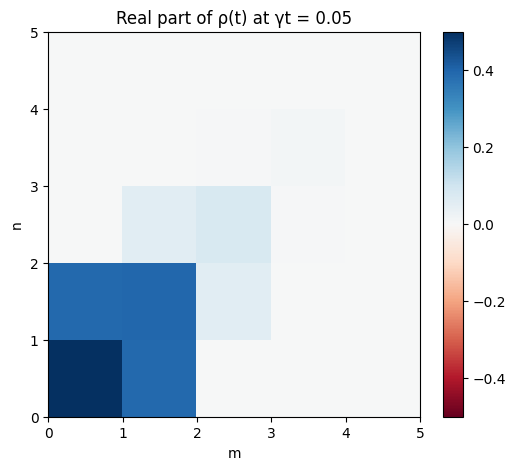

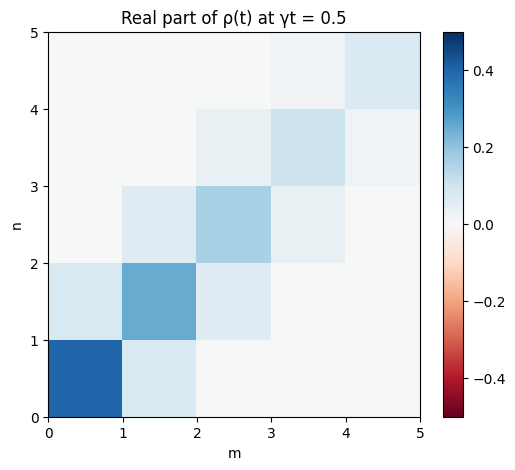

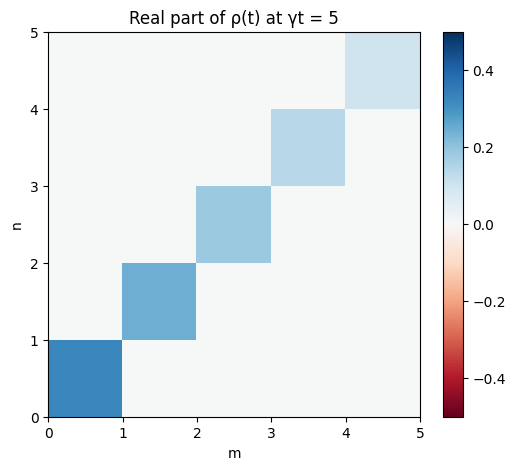

In [ ]:
# Parameters
omega=1
d=5
Gamma=1
N=3

# Operators
vec=np.sqrt(np.linspace(1,d-1,d-1))
A=np.diag(vec,+1)
Adag=A.T
id=np.identity(d)

# Hamiltonian
H=omega*(Adag@A+0.5)

# Liouville operator
LH=-1j*(sp.kron(H,id)-sp.kron(id,H.T))
L1=Gamma/2*(N+1)*(2*sp.kron(A,Adag.T)-sp.kron(Adag@A,id)-sp.kron(id,(Adag@A).T))
L2=Gamma/2*N*(2*sp.kron(Adag,A.T)-sp.kron(A@Adag,id)-sp.kron(id,(A@Adag).T))
L=LH+L1+L2

# Initial state: superposition
n=np.array([1,0,0,0,0])
m=np.array([0,1,0,0,0])
psi0=1/np.sqrt(2)*(n+m)
rho0=np.outer(psi0,psi0.conj()).flatten()

# Time evolution
t_steps=500
t_final=10
t_span=np.linspace(0, t_final, t_steps)

def rhodot(t, rho):
    return L@rho

sol=solve_ivp(rhodot, (t_span[0], t_span[-1]), rho0, t_eval=t_span)

# Times to evaluate: γt = 0.05, 0.5, 5  -> t = 0.05 / Gamma, etc.
time_targets = [0.05, 0.5, 5]  # γt, since Γ = 1 here, t = γt
indices = [np.argmin(np.abs(t_span - t)) for t in time_targets]

# Plotting
for idx, t_index in enumerate(indices):
    rho_t = sol.y[:, t_index].reshape((d, d))

    fig, (ax1) = plt.subplots(1, 1, figsize=(6, 5))

    # Plot real part
    c1 = ax1.pcolor(np.real(rho_t), cmap='RdBu', vmin=-0.5, vmax=0.5)
    fig.colorbar(c1, ax=ax1)
    ax1.set_title(f'ρ(t) at γt = {time_targets[idx]}')
    ax1.set_xlabel('m')
    ax1.set_ylabel('n')
    plt.show()


# Exercise 19

a)

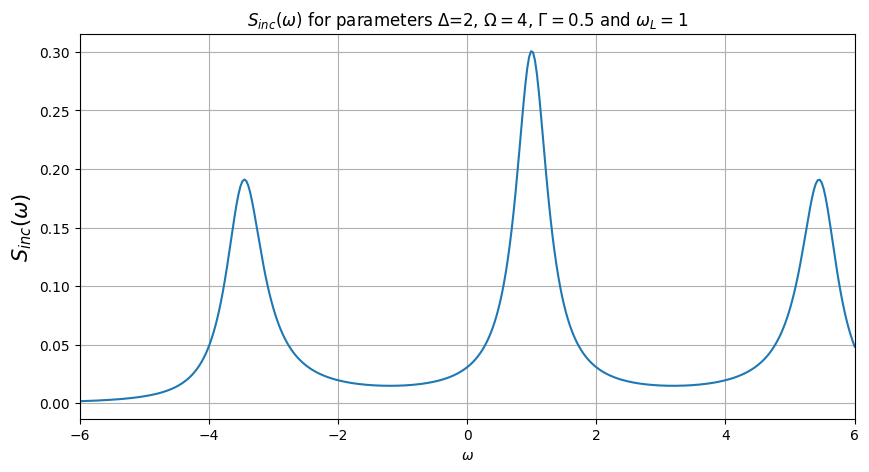

In [93]:
from scipy.linalg import null_space
Delta=2     #Level splitting
Omega=4     #Rabi frequency
Gamma=0.5     #atomic decay rate
omL=1

Id=np.identity(2)
Id2=np.identity(4)
SM=np.array([[0,0],[1,0]])  #sigma_- and \sigma_+ operators for the atom
SP=SM.T
H0=Delta*SP@SM         #bare Hamiltonian
H1=Omega/2*(SP+SM)     #driving Hamiltonian
H=H0+H1                #full atom Hamiltonian
 
#Liouville operator
LH=-1j*(np.kron(H,Id)-np.kron(Id,H.T))
LGamma= Gamma/2*( 2* np.kron(SM,SP.T)-np.kron(SP@SM,Id)-np.kron(Id,(SP@SM).T))
L=LH+LGamma #total Liouville operator

trace_vec=np.array([1,0,0,1]) #trace
v0=null_space(L)
rho0=v0/(trace_vec@v0)

#steady state
SM_mean=trace_vec@np.kron(SM,Id)@rho0   #SM- < SM> operator
dSM=np.kron(SM-SM_mean*Id,Id)
 
steps=401
omvec=np.linspace(-6,6,steps)
spec=np.zeros(steps)
for x in range(steps):
    om=omvec[x]+1j*10**(-10) # add small imaginary offset to avoid division by zero
    spec[x]=-2*Gamma*np.real(trace_vec@np.kron(SP,Id)@np.linalg.inv(1j*(om-omL)*Id2+L)@dSM@rho0
 ) #spectrum
 #Plot results:
fig, ax = plt.subplots(1,figsize=(10,5))
plt.plot(omvec,spec)
ax.set_ylabel(r'$S_{inc}(\omega)$ ', fontsize =15)
ax.set_xlabel(r'$\omega$')
ax.grid()
ax.set_xlim(-6,6)
ax.set_title(r'$S_{inc}(\omega)$ for parameters $\Delta$=2, $\Omega=4$, $\Gamma=0.5$ and $\omega_L=1$')
plt.show()

b)

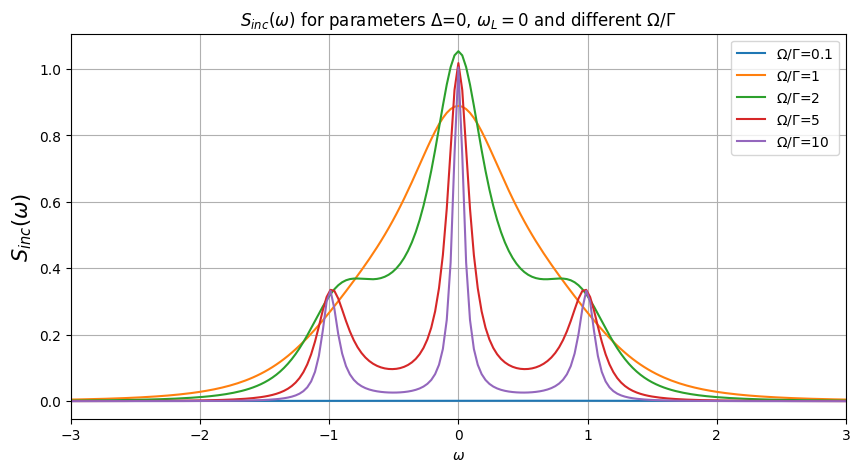

In [36]:
Delta=0     #Level splitting
Omega=1     #Rabi frequency
Gamma=[10,1,0.5,0.2,0.1]     #atomic decay rate
omL=0

#plots
fig, ax = plt.subplots(1,figsize=(10,5))
ax.set_ylabel(r'$S_{inc}(\omega)$ ', fontsize =15)
ax.set_xlabel(r'$\omega$')
ax.grid()
ax.set_xlim(-3,3)
ax.set_title(r'$S_{inc}(\omega)$ for parameters $\Delta$=0, $\omega_L=0$ and different $\Omega / \Gamma$')
label=[r'$\Omega / \Gamma$=0.1',r'$\Omega / \Gamma$=1',r'$\Omega / \Gamma$=2',r'$\Omega / \Gamma$=5',r'$\Omega / \Gamma$=10']

Id=np.identity(2)
Id2=np.identity(4)
SM=np.array([[0,0],[1,0]])  #sigma_- and \sigma_+ operators for the atom
SP=SM.T
H0=Delta*SP@SM         #bare Hamiltonian
H1=Omega/2*(SP+SM)     #driving Hamiltonian
H=H0+H1                #full atom Hamiltonian

for i in range(len(Gamma)): 
#Liouville operator
    LH=-1j*(np.kron(H,Id)-np.kron(Id,H.T))
    LGamma= Gamma[i]/2*( 2* np.kron(SM,SP.T)-np.kron(SP@SM,Id)-np.kron(Id,(SP@SM).T))
    L=LH+LGamma #total Liouville operator

    trace_vec=np.array([1,0,0,1]) #trace
    v0=null_space(L)
    rho0=v0/(trace_vec@v0)

    #steady state
    SM_mean=trace_vec@np.kron(SM,Id)@rho0   #SM- < SM> operator
    dSM=np.kron(SM-SM_mean*Id,Id)
    
    steps=401
    omvec=np.linspace(-6,6,steps)
    spec=np.zeros(steps)
    for x in range(steps):
        om=omvec[x]+1j*10**(-10) # add small imaginary offset to avoid division by zero
        spec[x]=-2*Gamma[i]*np.real(trace_vec@np.kron(SP,Id)@np.linalg.inv(1j*(om-omL)*Id2+L)@dSM@rho0
    ) #spectrum
 #Plot results:
    plt.plot(omvec,spec,label=label[i])
    #g=Omega/Gamma[i]
    #print(g)
    plt.legend()
    
plt.show()

c)

0.0
5.0
10.0


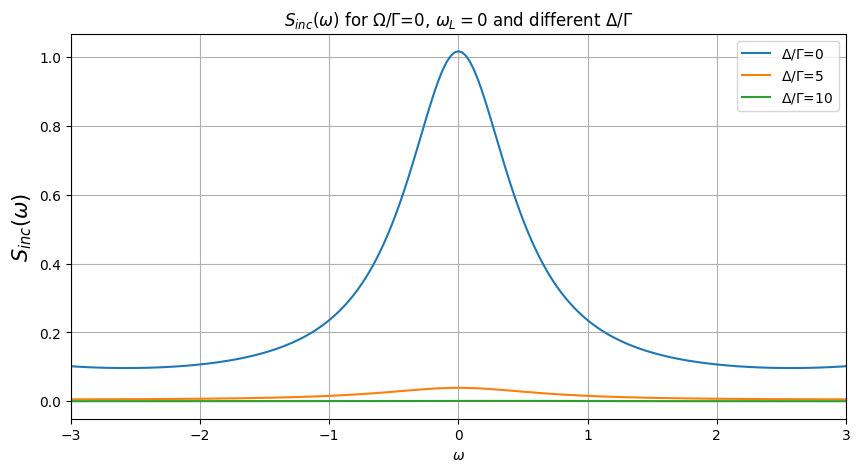

In [ ]:
Omega=5     #Level splitting
Gamma=1     #Rabi frequency
Delta=[0,5,10]     #atomic decay rate
omL=0

#plots
fig, ax = plt.subplots(1,figsize=(10,5))
ax.set_ylabel(r'$S_{inc}(\omega)$ ', fontsize =15)
ax.set_xlabel(r'$\omega$')
ax.grid()
ax.set_xlim(-3,3)
ax.set_title(r'$S_{inc}(\omega)$ for $\Omega/\Gamma$=0, $\omega_L=0$ and different $\Delta / \Gamma$')
label=[r'$\Delta / \Gamma$=0',r'$\Delta / \Gamma$=5',r'$\Delta / \Gamma$=10']

Id=np.identity(2)
Id2=np.identity(4)
SM=np.array([[0,0],[1,0]])  #sigma_- and \sigma_+ operators for the atom
SP=SM.T

for i in range(len(Delta)): 
    H0=Delta[i]*SP@SM         #bare Hamiltonian
    H1=Omega/2*(SP+SM)     #driving Hamiltonian
    H=H0+H1                #full atom Hamiltonian
#Liouville operator
    LH=-1j*(np.kron(H,Id)-np.kron(Id,H.T))
    LGamma= Gamma/2*( 2* np.kron(SM,SP.T)-np.kron(SP@SM,Id)-np.kron(Id,(SP@SM).T))
    L=LH+LGamma #total Liouville operator

    trace_vec=np.array([1,0,0,1]) #trace
    v0=null_space(L)
    rho0=v0/(trace_vec@v0)

    #steady state
    SM_mean=trace_vec@np.kron(SM,Id)@rho0   #SM- < SM> operator
    dSM=np.kron(SM-SM_mean*Id,Id)
    
    steps=401
    omvec=np.linspace(-6,6,steps)
    spec=np.zeros(steps)
    for x in range(steps):
        om=omvec[x]+1j*10**(-10) # add small imaginary offset to avoid division by zero
        spec[x]=-2*Gamma*np.real(trace_vec@np.kron(SP,Id)@np.linalg.inv(1j*(om-omL)*Id2+L)@dSM@rho0
    ) #spectrum
 #Plot results:
    plt.plot(omvec,spec,label=label[i])
    #g=Delta[i]/Gamma
    #print(g)
    plt.legend()
    
plt.show()

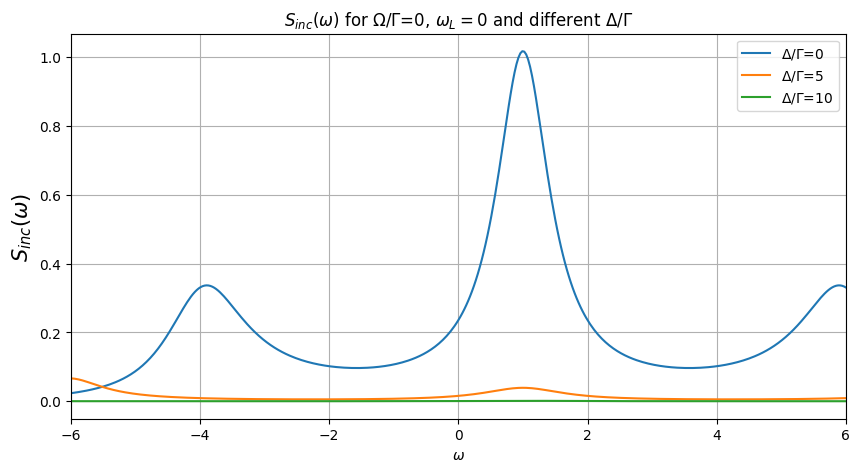

In [95]:
Omega=5     #Level splitting
Gamma=1     #Rabi frequency
Delta=[0,5,10]     #atomic decay rate
omL=1

#plots
fig, ax = plt.subplots(1,figsize=(10,5))
ax.set_ylabel(r'$S_{inc}(\omega)$ ', fontsize =15)
ax.set_xlabel(r'$\omega$')
ax.grid()
ax.set_xlim(-6,6)
ax.set_title(r'$S_{inc}(\omega)$ for $\Omega/\Gamma$=0, $\omega_L=0$ and different $\Delta / \Gamma$')
label=[r'$\Delta / \Gamma$=0',r'$\Delta / \Gamma$=5',r'$\Delta / \Gamma$=10']

Id=np.identity(2)
Id2=np.identity(4)
SM=np.array([[0,0],[1,0]])  #sigma_- and \sigma_+ operators for the atom
SP=SM.T

for i in range(len(Delta)): 
    H0=Delta[i]*SP@SM         #bare Hamiltonian
    H1=Omega/2*(SP+SM)     #driving Hamiltonian
    H=H0+H1                #full atom Hamiltonian
#Liouville operator
    LH=-1j*(np.kron(H,Id)-np.kron(Id,H.T))
    LGamma= Gamma/2*( 2* np.kron(SM,SP.T)-np.kron(SP@SM,Id)-np.kron(Id,(SP@SM).T))
    L=LH+LGamma #total Liouville operator

    trace_vec=np.array([1,0,0,1]) #trace
    v0=null_space(L)
    rho0=v0/(trace_vec@v0)

    #steady state
    SM_mean=trace_vec@np.kron(SM,Id)@rho0   #SM- < SM> operator
    dSM=np.kron(SM-SM_mean*Id,Id)
    
    steps=401
    omvec=np.linspace(-6,6,steps)
    spec=np.zeros(steps)
    for x in range(steps):
        om=omvec[x]+1j*10**(-10) # add small imaginary offset to avoid division by zero
        spec[x]=-2*Gamma*np.real(trace_vec@np.kron(SP,Id)@np.linalg.inv(1j*(om-omL)*Id2+L)@dSM@rho0
    ) #spectrum
 #Plot results:
    plt.plot(omvec,spec,label=label[i])
    #g=Delta[i]/Gamma
    #print(g)
    plt.legend()
    
plt.show()

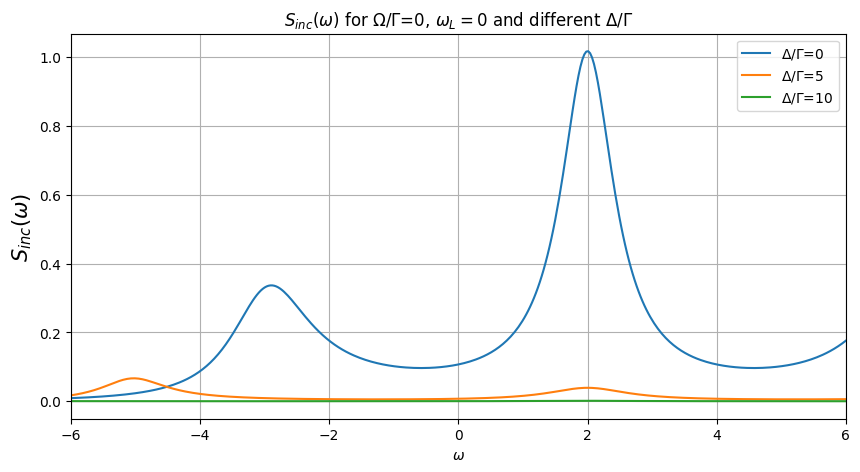

In [96]:
Omega=5     #Level splitting
Gamma=1     #Rabi frequency
Delta=[0,5,10]     #atomic decay rate
omL=2

#plots
fig, ax = plt.subplots(1,figsize=(10,5))
ax.set_ylabel(r'$S_{inc}(\omega)$ ', fontsize =15)
ax.set_xlabel(r'$\omega$')
ax.grid()
ax.set_xlim(-6,6)
ax.set_title(r'$S_{inc}(\omega)$ for $\Omega/\Gamma$=0, $\omega_L=0$ and different $\Delta / \Gamma$')
label=[r'$\Delta / \Gamma$=0',r'$\Delta / \Gamma$=5',r'$\Delta / \Gamma$=10']

Id=np.identity(2)
Id2=np.identity(4)
SM=np.array([[0,0],[1,0]])  #sigma_- and \sigma_+ operators for the atom
SP=SM.T

for i in range(len(Delta)): 
    H0=Delta[i]*SP@SM         #bare Hamiltonian
    H1=Omega/2*(SP+SM)     #driving Hamiltonian
    H=H0+H1                #full atom Hamiltonian
#Liouville operator
    LH=-1j*(np.kron(H,Id)-np.kron(Id,H.T))
    LGamma= Gamma/2*( 2* np.kron(SM,SP.T)-np.kron(SP@SM,Id)-np.kron(Id,(SP@SM).T))
    L=LH+LGamma #total Liouville operator

    trace_vec=np.array([1,0,0,1]) #trace
    v0=null_space(L)
    rho0=v0/(trace_vec@v0)

    #steady state
    SM_mean=trace_vec@np.kron(SM,Id)@rho0   #SM- < SM> operator
    dSM=np.kron(SM-SM_mean*Id,Id)
    
    steps=401
    omvec=np.linspace(-6,6,steps)
    spec=np.zeros(steps)
    for x in range(steps):
        om=omvec[x]+1j*10**(-10) # add small imaginary offset to avoid division by zero
        spec[x]=-2*Gamma*np.real(trace_vec@np.kron(SP,Id)@np.linalg.inv(1j*(om-omL)*Id2+L)@dSM@rho0
    ) #spectrum
 #Plot results:
    plt.plot(omvec,spec,label=label[i])
    #g=Delta[i]/Gamma
    #print(g)
    plt.legend()
    
plt.show()

The weight of the peaks doesn't change due to the detuning but the position does. It is shiftet by the detuning